# WINN — Wigner-Informed Neural Network — Interpretable Nuclear Mass Model

We generalize the supermultiplet mass formula
$$BE \approx a(A) + b(A)\,\mathcal{C}_2[\mathrm{SU}(4)]$$
into a modern, interpretable ML framework. The model learns eight $(N,Z)$-dependent coupling functions that multiply eight known physics terms:
$$
BE = a + b Z^2 + c T_z^2 + d N_{\hbar\omega}
+ e \mathcal{C}_2[\mathrm{SU}(3)]
+ f \mathcal{C}_3[\mathrm{SU}(3)]
+ g \mathcal{C}_2[\mathrm{SU}(4)]
+ h \mathcal{C}_4[\mathrm{SU}(4)]
$$

We construct a feed-forward network that maps $(N, Z)$ to the coupling strengths $\{a, b, c, d, e, f, g, h\}$. The binding energy prediction is the *dot product* of these 8 learned coefficients with the 8 physics terms.

## 1 — Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import symass
from symass import load_dataframe, SOAP, build_gk_indices, train, train_pinn, evaluate

torch.manual_seed(1)
np.random.seed(1)

TARGETS = ['BE_total_MeV']

/Users/phongdang/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2 — Data

Load nuclear masses, filtered to $Z \geq 8$, $N \geq 8$.

In [2]:
df = symass.load_dataframe(keep_extrapolated=False, Zmin=8, Nmin=8)
df = df[df[TARGETS[0]].notna()].reset_index(drop=True)

A_raw      = df['A'].to_numpy(dtype=np.float32)
N_raw      = df['N'].to_numpy(dtype=np.float32)
Z_raw      = df['Z'].to_numpy(dtype=np.float32)
N_int      = df['N'].to_numpy(dtype=np.int32)
Z_int      = df['Z'].to_numpy(dtype=np.int32)
ame_source = (df['ame_source'].to_numpy()
              if 'ame_source' in df.columns
              else np.full(len(df), 'AME2016'))

print(f'Total nuclides : {len(df)}')
print(f'AME2016        : {(ame_source == "AME2016").sum()}')
print(f'AME2020 (new)  : {(ame_source == "AME2020").sum()}')
print(f'BE range       : {df[TARGETS[0]].min():.1f} – {df[TARGETS[0]].max():.1f} MeV')

  [warn] Could not load pickle (ModuleNotFoundError: No module named 'numpy._core.numeric').
         Falling back to CSV — consider re-running src/build.py to rebuild the pickle in this environment.
Total nuclides : 2457
AME2016        : 2386
AME2020 (new)  : 71
BE range       : 127.6 – 1958.5 MeV


## 3 — Train / Test / Val Split

Nuclei measured in AME2016 form the train+test pool
(80/20 random split); nuclei newly measured between 2016 and 2020 form the
validation set. The validation set is never touched during training or
hyperparameter tuning---it is a genuine extrapolation benchmark.

In [4]:
idx_2016 = np.where(ame_source == 'AME2016')[0]
idx_val  = np.where(ame_source == 'AME2020')[0]

rng   = np.random.RandomState(0)          # same seed as FINN.ipynb
perm  = rng.permutation(len(idx_2016))
split = int(0.8 * len(idx_2016))
tr    = idx_2016[perm[:split]]
te    = idx_2016[perm[split:]]
val   = idx_val

print(f'Train : {len(tr):>4d}  nuclei')
print(f'Test  : {len(te):>4d}  nuclei')
print(f'Val   : {len(val):>4d}  nuclei  (AME2020 -- never used during training)')


Train : 1908  nuclei
Test  :  478  nuclei
Val   :   71  nuclei  (AME2020 -- never used during training)


## 4 — Build Indices for Garvey–Kelson Loss

In [8]:
gk_idx = build_gk_indices(N_int[tr], Z_int[tr])
n_gk   = 0 if gk_idx is None else len(gk_idx)
print(f'GK 6-body tuples in training set: {n_gk}')
print(f'  ({n_gk / len(tr) * 100:.1f}% of training nuclei in at least one GK relation)')

GK 6-body tuples in training set: 424
  (22.2% of training nuclei in at least one GK relation)


## 5 — Physics Feature Vector $\varphi$

The model prediction is a dot product:

$$BE(N,Z) = c(N,Z) \cdot \boldsymbol{\varphi}$$

where the coefficient vector $c(N,Z)$ comes from the NN and the feature vector $\varphi$ encodes
the known physics:

| Index $k$ | $\varphi_k$ | Physical meaning |
|-------|------|-----------------|
| 0 | 1 | Constant / offset (absorbs whatever left from symmetry operators) |
| 1 | $Z^2$ | Coulomb-like repulsion |
| 2 | $T_z^2$ | Isospin asymmetry |
| 3 | $N_{\hbar\omega}$ | Harmonic-oscillator quanta |
| 4 | $\mathcal{C}_2[\rm SU(3)]$ | Quadrupole deformation |
| 5 | $\mathcal{C}_3[\rm SU(3)]$ | Triaxiality |
| 6 | $\mathcal{C}_2[\rm SU(4)]$ | Two-body spin–isospin force |
| 7 | $\mathcal{C}_4[\rm SU(4)]$ | Four-body spin–isospin force |

In [3]:
T_z  = df['T_z'].to_numpy(dtype=np.float32)
Nhw  = df['Nhw'].to_numpy(dtype=np.float32)
C2_3 = df['C2_3'].to_numpy(dtype=np.float32)
C3_3 = df['C3_3'].to_numpy(dtype=np.float32)
C2_4 = df['C2_4'].to_numpy(dtype=np.float32)
C4_4 = df['C4_4'].to_numpy(dtype=np.float32)

# phi shape: (n, 8) -- [1, Z^2, T_z^2, N_hw, C2(SU3), C3(SU3), C2(SU4), C4(SU4)]
phi = np.stack([
    np.ones_like(A_raw),   # constant
    Z_raw ** 2,            # Z^2
    T_z   ** 2,            # T_z^2
    Nhw,                   # N_hw
    C2_3,                  # C_2[SU(3)]
    C3_3,                  # C_3[SU(3)]
    C2_4,                  # C_2[SU(4)]
    C4_4,                  # C_4[SU(4)]
], axis=1).astype(np.float32)

y = df[TARGETS].to_numpy(dtype=np.float32)
BE_true = y.ravel()   # (n,) experimental binding energies in MeV

phi_names = ['1', 'Z^2', 'T_z^2', 'N_hw', 'C2[SU3]', 'C3[SU3]', 'C2[SU4]', 'C4[SU4]']
print(f'{"Feature":<12}  {"min":>12}  {"max":>12}  {"std":>12}')
print('-' * 52)
for i, name in enumerate(phi_names):
    print(f'{name:<12}  {phi[:,i].min():>12.1f}  {phi[:,i].max():>12.1f}  {phi[:,i].std():>12.1f}')


Feature                min           max           std
----------------------------------------------------
1                      1.0           1.0           0.0
Z^2                   64.0       12100.0        2806.0
T_z^2                  0.0         870.2         202.8
N_hw                  12.0        1118.0         276.2
C2[SU3]                0.0       10426.0        2873.9
C3[SU3]           -12523.8      232322.2       58968.6
C2[SU4]                0.0        1979.5         463.1
C4[SU4]                0.0      250347.7       46948.7


## 6 — Normalisation: CoeffNorm

Standard Z-score normalisation centres *and* scales every feature. `CoeffNorm` is purpose-built
for the bilinear architecture:

```
X = [ N_norm | Z_norm | phi_scaled ]
```

**N_norm, Z_norm** — full Z-score (mean and std from training). These (proton and neutron numbers) are the only inputs to
the coefficient sub-network.

**phi_scaled** — divided by training std, but **not centred**. Two reasons:

1. The constant column ($\varphi_0 = 1$) has zero variance — subtracting its mean would destroy it.
2. If we centred $\varphi_k$ to 1, the coefficient $c_k(N,Z)$ would multiply $(\varphi_k − \mu_k)$ instead of $\varphi_k$. The coefficient would then represent "coupling relative to the mean nucleus", which is much harder to interpret. Keeping $\varphi$ uncentred means $c_k(N,Z)$ is literally the coupling strength at a particular $(N,Z)$.

**y** — standard Z-score. `phys_coeffs()` converts normalised NN output back to physical MeV:

$$a_\mathrm{phys}(N,Z) = c_{0,\mathrm{norm}} \cdot \sigma_y + \mu_y$$
$$c_{k,\mathrm{phys}}(N,Z) = c_{k,\mathrm{norm}} \cdot \sigma_y \;/\; \sigma_{\varphi_k} \quad (k \ge 1)$$

In [5]:
class CoeffNorm:
    # Normaliser for the CoeffNet (N,Z) bilinear architecture.

    def __init__(self, N, Z, phi, y):
        self.N_mean = float(N.mean());  self.N_std = float(N.std()) + 1e-8
        self.Z_mean = float(Z.mean());  self.Z_std = float(Z.std()) + 1e-8
        phi_std = phi.std(axis=0) + 1e-8
        phi_std[0] = 1.0          # constant column -- scale-only, never centred
        self.phi_std = phi_std
        self.y_mean = y.mean(axis=0)
        self.y_std  = y.std(axis=0) + 1e-8

    def transform(self, N, Z, phi):
        # Returns (n, 10): [N_norm | Z_norm | phi_scaled]
        N_norm = ((N - self.N_mean) / self.N_std).astype(np.float32)[:, None]
        Z_norm = ((Z - self.Z_mean) / self.Z_std).astype(np.float32)[:, None]
        phi_sc = (phi / self.phi_std).astype(np.float32)
        return np.concatenate([N_norm, Z_norm, phi_sc], axis=1)

    def transform_y(self, y):
        return ((y - self.y_mean) / self.y_std).astype(np.float32)

    def inverse_y(self, y):
        return y * self.y_std + self.y_mean

    def phys_coeffs(self, coeffs_norm):
        # Convert normalised coefficients to physical units [MeV]
        c = coeffs_norm.copy()
        c[:, 0] = c[:, 0] * float(self.y_std) + float(self.y_mean)
        c[:, 1:] = c[:, 1:] * float(self.y_std) / self.phi_std[1:]
        return c

    def NZ_norm_tensor(self, N, Z):
        N_n = ((N - self.N_mean) / self.N_std).astype(np.float32)
        Z_n = ((Z - self.Z_mean) / self.Z_std).astype(np.float32)
        return torch.tensor(np.stack([N_n, Z_n], axis=1))

In [6]:
norm = CoeffNorm(N_raw[tr], Z_raw[tr], phi[tr], y[tr])

X_tr  = torch.tensor(norm.transform(N_raw[tr],  Z_raw[tr],  phi[tr]))
y_tr  = torch.tensor(norm.transform_y(y[tr]))
X_te  = torch.tensor(norm.transform(N_raw[te],  Z_raw[te],  phi[te]))
y_te  = torch.tensor(norm.transform_y(y[te]))
X_val = torch.tensor(norm.transform(N_raw[val], Z_raw[val], phi[val]))
y_val = torch.tensor(norm.transform_y(y[val]))

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

print('X_tr shape:', X_tr.shape, ' -- [N_norm, Z_norm, phi_scaled x8]')

# Shim so evaluate() can call inverse_y without knowing CoeffNorm
class _NormShim:
    def inverse_y(self_, yn):
        return norm.inverse_y(yn)
norm_shim = _NormShim()

X_tr shape: torch.Size([1908, 10])  -- [N_norm, Z_norm, phi_scaled x8]


## 7 — CoeffNet Architecture

```
Input X  (B, 10)
    |
    +-- NZ_norm = X[:, :2]  -->  Linear(2,64) --> ReLU
    |   (N_norm, Z_norm)         Linear(64,128) --> ReLU       --> 8 coefficients  (B, 8)
    |                            Linear(128,64) --> ReLU            a, b, c, d, e, f, g, h
    |                            Linear(64, 8)
    |
    +-- phi = X[:, 2:]      -->  element-wise multiply  -->  sum  -->  BE_norm  (B, 1)
        (phi_scaled, 8)                  ^
                                   (B,8) x (B,8)
```

The forward pass is a bilinear operation:

$$BE_\mathrm{norm} = \sum_{k=0}^{7} c_k(N,Z) \cdot \varphi_k$$

Key design properties:

- The coefficient sub-network sees only 2 inputs $(N,Z)$ — it cannot memorize individual
  nuclei, only learn smooth $(N,Z)$ patterns.
- The physics features act as inductive bias that guides what the network can express.
  The model cannot produce a prediction that is not a linear combination of the 8 physics terms.

In [7]:
class CoeffNet(nn.Module):
    """
    Bilinear nuclear mass model: BE = sum_k coeff_k(N,Z) * phi_k
    Input X shape (B, 2+K): cols 0-1 are (N_norm, Z_norm), cols 2+ are phi_scaled.
    """
    def __init__(self, n_coeffs=8, hidden=[64,128,64], activation=nn.PReLU): #[64, 64, 32]
        super().__init__()
        self.n_coeffs = n_coeffs

        def make_act(width):
            # PReLU gets one learnable slope per neuron (init 0.1)
            if activation is nn.PReLU:
                return nn.PReLU(num_parameters=width, init=0.1)
            return activation()

        layers = []
        in_dim = 2   # only (N_norm, Z_norm) enters the coefficient network
        for h in hidden:
            layers += [nn.Linear(in_dim, h), make_act(h)]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_coeffs))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        NZ_norm = x[:, :2]            # (B, 2) -- to coefficient network
        phi     = x[:, 2:]            # (B, K) -- physics features
        coeffs  = self.net(NZ_norm)   # (B, K) -- learned coupling strengths
        return (coeffs * phi).sum(dim=1, keepdim=True)   # (B, 1)

    @torch.no_grad()
    def get_coefficients(self, NZ_norm):
        """Evaluate the coupling functions on an arbitrary (N,Z) grid."""
        self.eval()
        return self.net(NZ_norm)

ACTIVATION = nn.ReLU
loss_fn   = nn.MSELoss()
hidden    = [64, 128, 64]

## 8 — Model 1: CoeffNet-MSE

Baseline trained with plain mean-squared-error loss.

**Optimiser**: SOAP (second-order, Shampoo-like)

In [17]:
torch.manual_seed(1)
model1 = CoeffNet(hidden=hidden, activation=ACTIVATION)
opt1   = SOAP(model1.parameters(), lr=1e-3, betas=(0.95, 0.95),
              weight_decay=0.01, precondition_frequency=10)

history1 = train(model1, loader, opt1, loss_fn,
                 epochs=1000, print_every=100, label='CoeffNet-MSE')

  [CoeffNet-MSE]  epoch    100  loss 0.000009
  [CoeffNet-MSE]  epoch    200  loss 0.000005
  [CoeffNet-MSE]  epoch    300  loss 0.000008
  [CoeffNet-MSE]  epoch    400  loss 0.000003
  [CoeffNet-MSE]  epoch    500  loss 0.000002
  [CoeffNet-MSE]  epoch    600  loss 0.000003
  [CoeffNet-MSE]  epoch    700  loss 0.000004
  [CoeffNet-MSE]  epoch    800  loss 0.000004
  [CoeffNet-MSE]  epoch    900  loss 0.000001
  [CoeffNet-MSE]  epoch   1000  loss 0.000002


## 9 — Model 2: CoeffNet-PINN

MSE + GK regularisation. The coefficient network sees the GK penalty as a signal to keep its coupling functions smooth and consistent, which directly benefits generalization to
the AME2020 validation nuclei.

In [50]:
torch.manual_seed(1)
model2 = CoeffNet(hidden=hidden, activation=ACTIVATION)
opt2   = SOAP(model2.parameters(), lr=1e-3, betas=(0.95, 0.95),
              weight_decay=0.01, precondition_frequency=10)

history2 = train_pinn(model2, loader, opt2, loss_fn,
                      X_tr, gk_idx, gk_lambda=0.15,
                      epochs=1000, print_every=100, label='CoeffNet-PINN')

  [CoeffNet-PINN]  epoch    100  loss 0.000004
  [CoeffNet-PINN]  epoch    200  loss 0.000002
  [CoeffNet-PINN]  epoch    300  loss 0.000005
  [CoeffNet-PINN]  epoch    400  loss 0.000002
  [CoeffNet-PINN]  epoch    500  loss 0.000002
  [CoeffNet-PINN]  epoch    600  loss 0.000004
  [CoeffNet-PINN]  epoch    700  loss 0.000001
  [CoeffNet-PINN]  epoch    800  loss 0.000002
  [CoeffNet-PINN]  epoch    900  loss 0.000002
  [CoeffNet-PINN]  epoch   1000  loss 0.000003


## 10 — Evaluation

RMSE and MAE in MeV. The validation RMSE is the key number — it measures extrapolation
to nuclei measured after the training data was fixed.

In [51]:
m1_tr  = evaluate(model1, X_tr,  y_tr,  norm=norm_shim)
m1_te  = evaluate(model1, X_te,  y_te,  norm=norm_shim)
m1_val = evaluate(model1, X_val, y_val, norm=norm_shim)

m2_tr  = evaluate(model2, X_tr,  y_tr,  norm=norm_shim)
m2_te  = evaluate(model2, X_te,  y_te,  norm=norm_shim)
m2_val = evaluate(model2, X_val, y_val, norm=norm_shim)

print(f"  {'Model':<20}  {'Train RMSE':>12}  {'Test RMSE':>10}"
      f"  {'Val RMSE':>10}  {'Train MAE':>10}  {'Val MAE':>9}")
print('  ' + chr(0x2500) * 78)
for name, m_tr, m_te, m_val in [
    ('CoeffNet-MSE',  m1_tr, m1_te, m1_val),
    ('CoeffNet-PINN', m2_tr, m2_te, m2_val),
]:
    print(f'  {name:<20}  {m_tr["rmse"]:>10.3f}  {m_te["rmse"]:>10.3f}'
          f'  {m_val["rmse"]:>10.3f}  {m_tr["mae"]:>10.3f}  {m_val["mae"]:>9.3f}')

  Model                   Train RMSE   Test RMSE    Val RMSE   Train MAE    Val MAE
  ──────────────────────────────────────────────────────────────────────────────
  CoeffNet-MSE               0.651       0.677       0.945       0.559      0.822
  CoeffNet-PINN              0.400       0.447       0.430       0.302      0.342


## 11 (Optional) — Save WINN model to disk

In [70]:
import pickle, torch

torch.save({
    'model_state': model2.state_dict(),
    'n_coeffs':    8,
    'hidden':      hidden,
}, '../work/winn_model.pt')

with open('../work/winn_norm.pkl', 'wb') as _f:
    pickle.dump(norm, _f)

print('Saved winn_model.pt and winn_norm.pkl')


Saved winn_model.pt and winn_norm.pkl


## 12 — Prediction Diagnostics

True-vs-predicted scatter and residual heatmap on the nuclear chart.

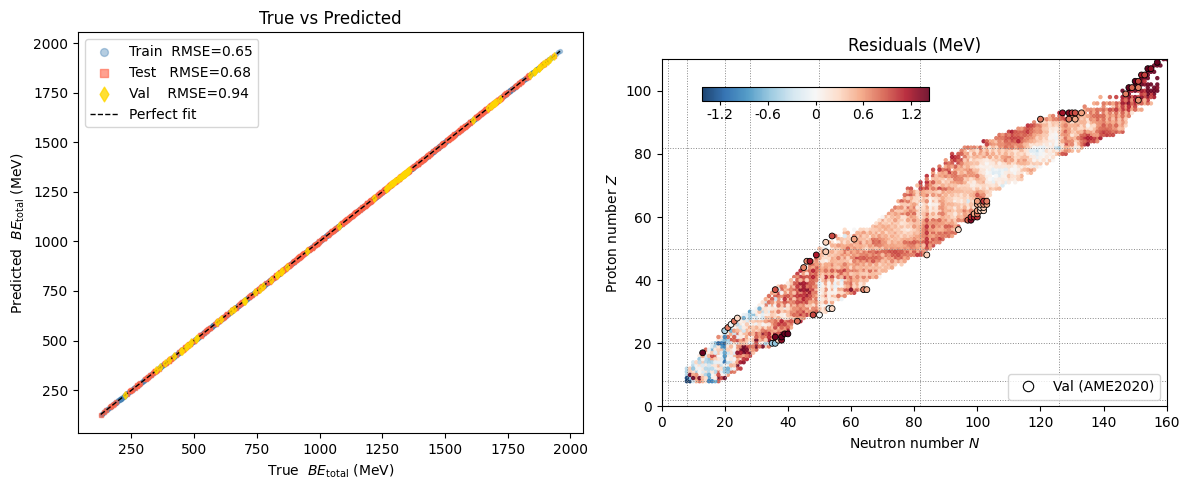

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'True vs Predicted'}, xlabel='True  $BE_\\mathrm{total}\\ (\\mathrm{MeV})$', ylabel='Predicted  $BE_\\mathrm{total}\\ (\\mathrm{MeV})$'>,
        <Axes: title={'center': 'Residuals (MeV)'}, xlabel='Neutron number $N$', ylabel='Proton number $Z$'>],
       dtype=object))

In [65]:
# CoeffNet-MSE
symass.plot_predictions(
    m1_tr, m1_te, N_int[tr], Z_int[tr], N_int[te], Z_int[te],
    target_name=TARGETS[0], residuals=True,
    val_metrics=m1_val, val_N=N_int[val], val_Z=Z_int[val],
)

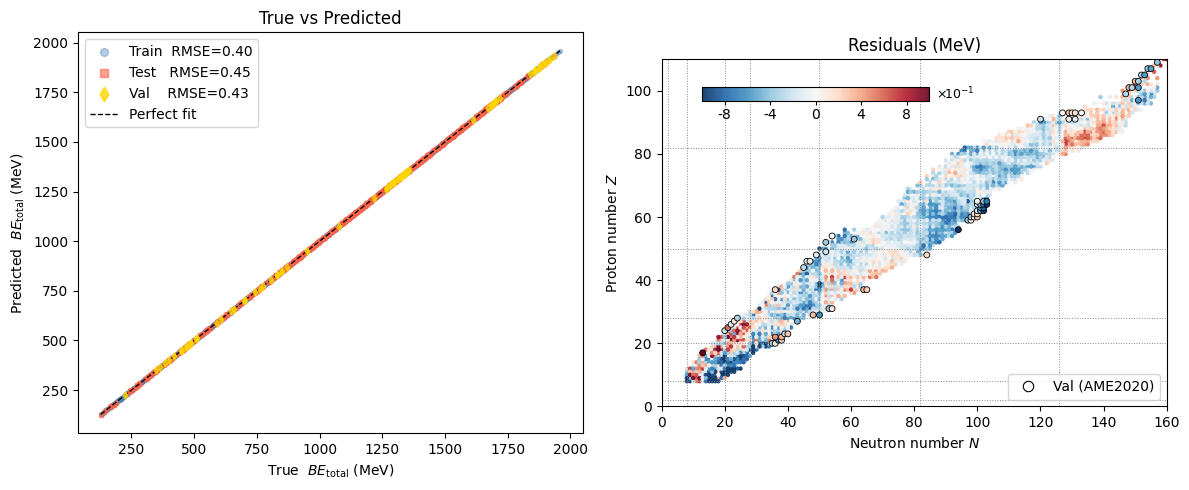

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'True vs Predicted'}, xlabel='True  $BE_\\mathrm{total}\\ (\\mathrm{MeV})$', ylabel='Predicted  $BE_\\mathrm{total}\\ (\\mathrm{MeV})$'>,
        <Axes: title={'center': 'Residuals (MeV)'}, xlabel='Neutron number $N$', ylabel='Proton number $Z$'>],
       dtype=object))

In [66]:
# CoeffNet-PINN
symass.plot_predictions(
    m2_tr, m2_te, N_int[tr], Z_int[tr], N_int[te], Z_int[te],
    target_name=TARGETS[0], residuals=True,
    val_metrics=m2_val, val_N=N_int[val], val_Z=Z_int[val],
)

## 13 — Relative Term Contributions on the Nuclear Chart

For each nucleus we plot the fractional contribution of each linear term:
$$\mathrm{frac}_k(N,Z) = \frac{c_k(N,Z)\,\varphi_k}{BE_{\rm true}}$$

This is much more physically transparent than the raw coupling coefficients:
- A value of 0.05 means that term accounts for 5% of total binding energy at that nucleus.
- The eight panels sum to $BE_{\rm pred}/BE_{\rm true} \approx 1$ per nucleus.
- The SU(4)/SU(3) panels directly reveal where on the nuclear chart each symmetry matters.


In [14]:
# Relative contribution labels: c_k(N,Z) * phi_k / BE_true
CONTRIB_COLS = [
    r'$a/\mathrm{BE}$',
    r'$bZ^2/\mathrm{BE}$',
    r'$cT_z^2/\mathrm{BE}$',
    r'$dN_{\hbar\omega}/\mathrm{BE}$',
    r'$e\mathcal{C}_2[\mathrm{SU(3)}]/\mathrm{BE}$',
    r'$f\mathcal{C}_3[\mathrm{SU(3)}]/\mathrm{BE}$',
    r'$g\mathcal{C}_2[\mathrm{SU(4)}]/\mathrm{BE}$',
    r'$h\mathcal{C}_4[\mathrm{SU(4)}]/\mathrm{BE}$',
]

def plot_contributions(model, norm, N_data, Z_data, phi_data, BE_true,
                       contrib_cols, title='', cmap='RdBu_r', ncols=2, figsize=(7,10),
                       savefig="figures/SU3SU4_contributions"):
    """
    Plot the fractional contribution of each phi-term to binding energy:
        frac_k(N,Z) = c_k(N,Z) * phi_k / BE_true
    Each panel shows where on the nuclear chart that physics term is
    most (red) or least / negative (blue) important.
    The contributions sum to BE_pred / BE_true ~ 1 per nucleus.
    """
    NZ_tensor   = norm.NZ_norm_tensor(N_data.astype(np.float32),
                                      Z_data.astype(np.float32))
    coeffs_norm = model.get_coefficients(NZ_tensor).numpy()   # (n, K)
    coeffs_phys = norm.phys_coeffs(coeffs_norm)               # (n, K) in MeV

    # Fractional contributions
    contributions = coeffs_phys * phi_data / BE_true[:, None]  # (n, K)

    df_c = pd.DataFrame({'N': N_data, 'Z': Z_data})
    for k, col in enumerate(contrib_cols):
        df_c[col] = contributions[:, k]

    if title:
        print(f'\n{title}')
    symass.plot_maps(df_c, contrib_cols, ncols=ncols, figsize=figsize, cmap=cmap, title_out=False, savefig=savefig)


/var/folders/5q/15j1klc15sldk4jwl8pzrjp40000gn/T/ipykernel_85052/3183633323.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c[:, 0] = c[:, 0] * float(self.y_std) + float(self.y_mean)
/var/folders/5q/15j1klc15sldk4jwl8pzrjp40000gn/T/ipykernel_85052/3183633323.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c[:, 1:] = c[:, 1:] * float(self.y_std) / self.phi_std[1:]


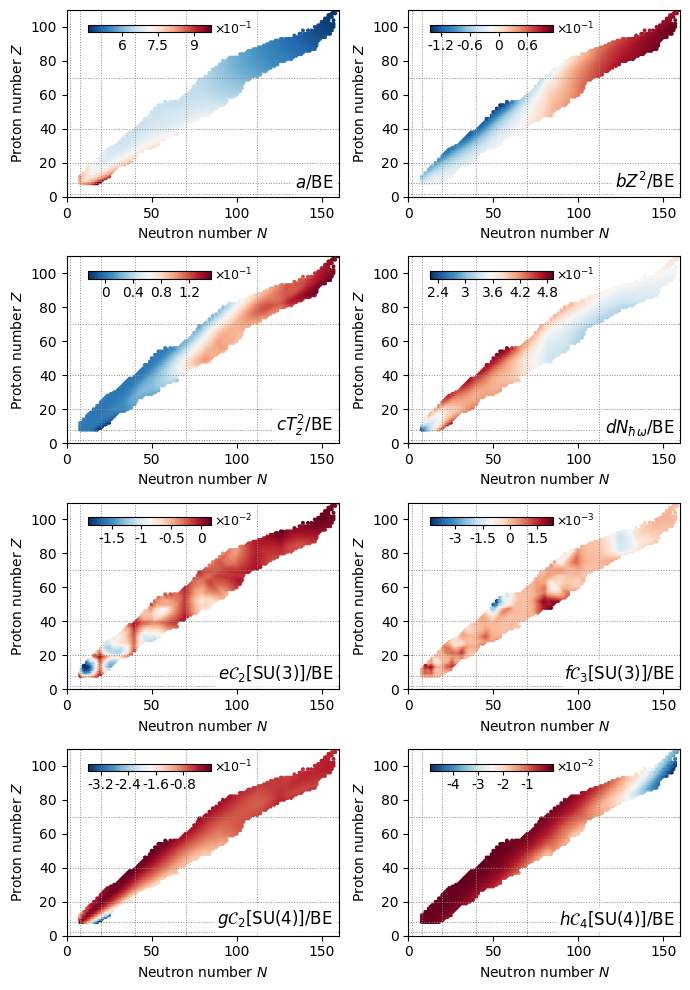

In [68]:
plot_contributions(model1, norm, N_int, Z_int, phi, BE_true,
                   contrib_cols=CONTRIB_COLS,
                   savefig="figures/SU3SU4_contributions_8terms",
                   # title='CoeffNet-MSE -- fractional contributions to BE'
                  )

/var/folders/5q/15j1klc15sldk4jwl8pzrjp40000gn/T/ipykernel_85052/3183633323.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c[:, 0] = c[:, 0] * float(self.y_std) + float(self.y_mean)
/var/folders/5q/15j1klc15sldk4jwl8pzrjp40000gn/T/ipykernel_85052/3183633323.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c[:, 1:] = c[:, 1:] * float(self.y_std) / self.phi_std[1:]


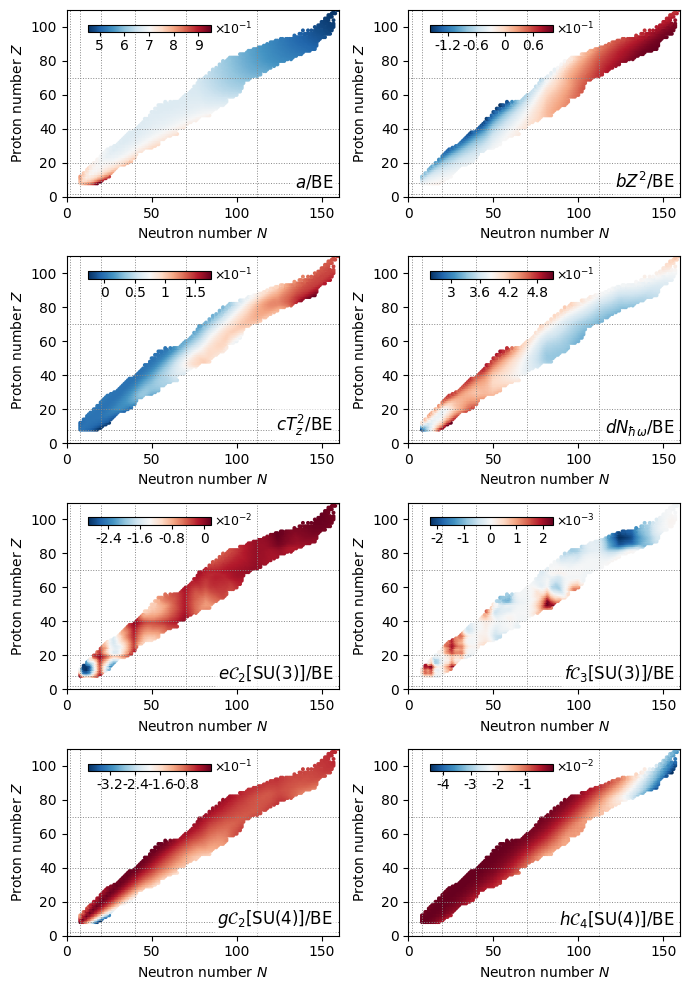

In [69]:
plot_contributions(model2, norm, N_int, Z_int, phi, BE_true,
                   contrib_cols=CONTRIB_COLS,
                   savefig="figures/SU3SU4_contributions_8terms",
                   #title='CoeffNet-PINN -- fractional contributions to BE'
                  )

## 14 — Residual analysis by parity (pairing diagnostic)

A possible test is to analyze the mass residuals separately for even–even, odd-$A$, and
odd–odd nuclei. If pairing effects are not fully captured, one often observes systematic
underbinding of even–even nuclei, systematic overbinding of odd–odd nuclei, and noticeable
odd–even oscillations in the residuals.

class       count   mean (MeV)      std     RMSE
------------------------------------------------
even-even     642       -0.201    0.400    0.447
odd-A        1230       -0.082    0.369    0.378
odd-odd       585       -0.254    0.349    0.432


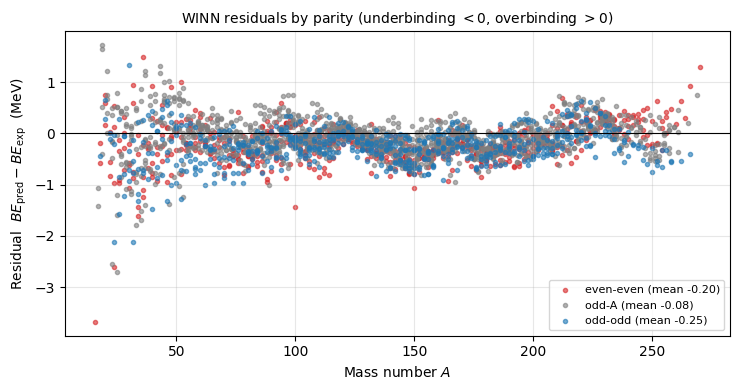

In [52]:
import matplotlib.pyplot as plt

# Residuals of the WINN (CoeffNet-PINN, model2), split by nucleon-number parity.
# residual = BE_pred - BE_exp   (negative => underbound, positive => overbound)
X_all_  = torch.tensor(norm.transform(N_raw, Z_raw, phi))
be_pred = norm.inverse_y(model2(X_all_).detach().numpy()).ravel()
residual = be_pred - BE_true

Ne, Ze = (N_int % 2 == 0), (Z_int % 2 == 0)
classes = {'even-even': Ne & Ze, 'odd-A': Ne ^ Ze, 'odd-odd': ~Ne & ~Ze}

print(f"{'class':<10}{'count':>7}{'mean (MeV)':>13}{'std':>9}{'RMSE':>9}")
print('-' * 48)
for name, m in classes.items():
    r = residual[m]
    print(f"{name:<10}{int(m.sum()):>7d}{r.mean():>13.3f}{r.std():>9.3f}{np.sqrt((r**2).mean()):>9.3f}")

# residual vs mass number, coloured by parity class
A_all  = (N_raw + Z_raw)
colors = {'even-even': 'tab:red', 'odd-A': 'tab:gray', 'odd-odd': 'tab:blue'}
fig, ax = plt.subplots(figsize=(7.5, 4))
for name, m in classes.items():
    ax.scatter(A_all[m], residual[m], s=9, alpha=0.6,
               color=colors[name], label=f'{name} (mean {residual[m].mean():+.2f})')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('Mass number $A$')
ax.set_ylabel(r'Residual  $BE_{\rm pred} - BE_{\rm exp}$  (MeV)')
ax.set_title('WINN residuals by parity (underbinding $<0$, overbinding $>0$)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('figures/residual_parity.png', dpi=200, bbox_inches='tight')
plt.show()

# class means near zero => pairing already captured; a systematic
# even-even(-) / odd-odd(+) split => residual pairing signal.